El diagrama Hertzsprung-Russell
==

Alumno
---
Pedro G. Villegas

Docentes
---
J.P. Calderón & R. Gamen

Resumen
---
El diagrama Hertzsprung-Russell (HR) resulta muy importante para entender y estudiar la evolución estelar tanto desde el punto de vista observacional como teórico. En él se pueden relacionar luminosidades o magnitudes absolutas de las estrellas con sus tipos espectrales, temperaturas efectivas o índices de color. Se pueden identificar claramente conjuntos de estrellas, que quedan determinados por las diferentes etapas de su evolución.

En esta práctica vamos a aprovechar algunas facilidades de visualización que nos brinda Python para
comprender mejor su importancia.

Recuerden leer la bibliografía accesible desde la Wiki de la materia.


Referencias
---
* [Práctica 08 (overleaf)](https://www.overleaf.com/read/cnwscfdkgjtn)

---

Ejercicio 1
---

Analice el diagrama Hertzsprung-Russell para la muestra de estrellas que se encuentra disponible en la página de la misión Nearby Stellar Systems Catalog for Exoplanet Imaging Missions1. La misma dispone de más de 2000 estrellas de hasta 30 pc de distancia y fue extraída del catálogo generado por Hipparcos. Puede consultar sus características principales en [Turnbull (2015)](https://ui.adsabs.harvard.edu/abs/2015arXiv151001731T/abstract).

In [3]:
import pandas as pd

hr = pd.read_csv ( 'Nstars_V1.csv', header = 0, na_values = "___" )

In [4]:
hr

,HIP,HD,GL/GJ,GL/LTT,COMMON,WDS,"sep("")",dM(mag),NPLANETS,RAhms,...,R*(Rsun),R_src,M*(Msun),M_src,log(g),log(g)_src,Age(Gyr),Age_src,AC-Gray,[Fe/H]-VF05
0,57,224789,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00 00 40.39,...,0.91,Turnbull,0.82,Turnbull,4.48,Gray,NaN,NaN,A,NaN
1,169,224953,GJ 1294A,LTT 9859,NaN,00021-6817,NaN,NaN,NaN,00 02 08.41,...,0.63,Turnbull,0.53,Turnbull,NaN,NaN,NaN,NaN,NaN,NaN
2,171,224930,GL 914A,LHS 101,NaN,00022+2705,0.8,3.07,NaN,00 02 09.65,...,0.92,Turnbull,0.91,Turnbull,4.27,Gray,NaN,NaN,I,NaN
3,263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00 03 19.02,...,0.51,Turnbull,0.45,Turnbull,NaN,NaN,NaN,NaN,NaN,NaN
4,375,NaN,NaN,NaN,NaN,00047+3416,NaN,NaN,NaN,00 04 40.15,...,NaN,NaN,0.62,Turnbull,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2342,118278,224619,G 266- 21,LHS 4055,NaN,NaN,NaN,NaN,NaN,23 59 28.12,...,0.89,Turnbull,0.88,Turnbull,4.49,Gray,NaN,NaN,I,NaN
2343,118281,224635,NaN,NaN,NaN,23595+3343,2.4,0.26,NaN,23 59 29.33,...,1.77,Turnbull,1.24,Turnbull,NaN,NaN,NaN,NaN,NaN,NaN
2344,118310,224660,NaN,NaN,NaN,23598+0640,NaN,NaN,NaN,23 59 47.82,...,0.86,Turnbull,0.71,Turnbull,NaN,NaN,NaN,NaN,A,NaN
2345,120005,79211,GL 338B,G 195- 18,NaN,09144+5241,NaN,NaN,NaN,09 14 26.19,...,0.53,Takeda,0.55,Takeda,4.76,Takeda,NaN,NaN,NaN,NaN


In [5]:
# Me dice que tipo de variable tiene cada columna
hr.dtypes

HIP               int64
HD               object
GL/GJ            object
GL/LTT           object
COMMON           object
WDS              object
sep(")          float64
dM(mag)         float64
NPLANETS        float64
RAhms            object
DEdms            object
RA(ICRS)        float64
DE(ICRS)        float64
pmRA            float64
pmDE            float64
Glon            float64
Glat            float64
d(pc)           float64
ePARX/PARX      float64
V               float64
e_V             float64
V_src            object
B-V             float64
e_B-V            object
B-V_src          object
Mv              float64
e_Mv             object
CombMag          object
V-K             float64
e_V-K           float64
K_src            object
Lbol_src         object
Lbol            float64
e_Lbol           object
SpType           object
CLASS            object
SPECTAG          object
EEID(AU)        float64
EEID(mas)       float64
FPB-Earth       float64
V-Earth(mag)    float64
Teff            

## Realice un diagrama color-magnitud de todas las estrellas del catálogo e identifique las diferentes regiones presentes.

In [6]:
def custom_axes ( a ):
    a.minorticks_on()
    a.yaxis.set_ticks_position ( 'both' )
    a.xaxis.set_ticks_position ( 'both' )
    a.tick_params ( which = 'major', direction = 'inout', length = 10 )
    a.tick_params ( which = 'minor', direction = 'in', length = 5 )
    a.tick_params ( direction = 'in', pad = 10 )  
    a.tick_params ( which = 'both', width = 1 )
    # La siguiente línea obliga al grafico a ser cuadrado:
    #a.set_aspect ( 1.0/axs.get_data_ratio(), adjustable = 'box' )
    a.grid ( which = 'major', color = 'black', linestyle = '--', linewidth = '1.0', alpha = 0.3 )
    a.grid ( which = 'minor', color = 'gray', linestyle = '-', linewidth = '1.0', alpha = 0.1 )
    plt.setp ( a.spines.values(), linewidth = 1.5 )

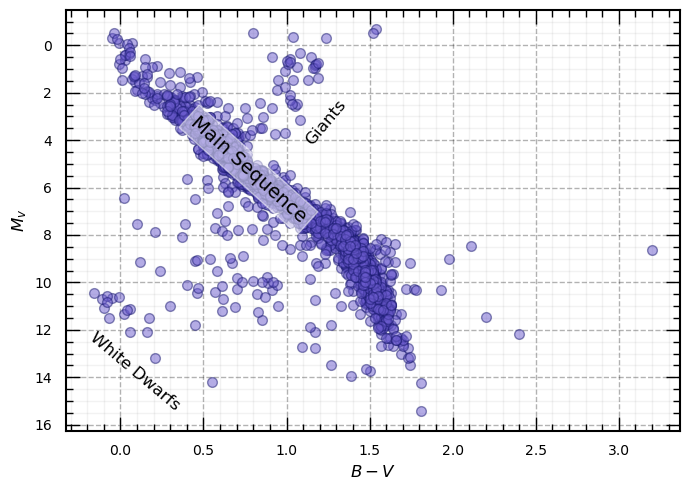

In [7]:
import matplotlib.pyplot as plt
                
fig, axs = plt.subplots ( figsize = (7,5), dpi = 100 )

plt.scatter ( 'B-V', 'Mv', data = hr, color = 'slateblue', edgecolors = 'midnightblue', 
             s = 7**2, alpha = 0.5, zorder = 10 )
axs.invert_yaxis()

# ·--·-- Textos ·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--

axs.annotate(str('Main Sequence'), color = "black", xy = (0.4,7),
                xytext = (0, 30), textcoords = 'offset points', 
                va = "center", rotation = -42, size = 14, zorder=50 ).set_bbox(dict(
    facecolor='white',  # background color
    alpha=0.5,  # background alpha
    edgecolor='white'  # border color
))

axs.annotate(str('Giants'), color = "k", xy = (1.1,5),
                xytext = (0, 30), textcoords = 'offset points', 
                va = "center", rotation = 50, size = 12, zorder=50 )

axs.annotate(str('White Dwarfs'), color = "k", xy = (-0.2,15.5),
                xytext = (0, 30), textcoords = 'offset points', 
                va = "center", rotation = -40, size = 12, zorder=50 )

# ·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--

axs.set_xlabel ( r'$B-V$', size = 12 )
axs.set_ylabel ( r'$M_v$', size = 12 )

custom_axes ( axs )
    
fig.tight_layout()
plt.show()  

##  Analice cómo varia el radio estelar.

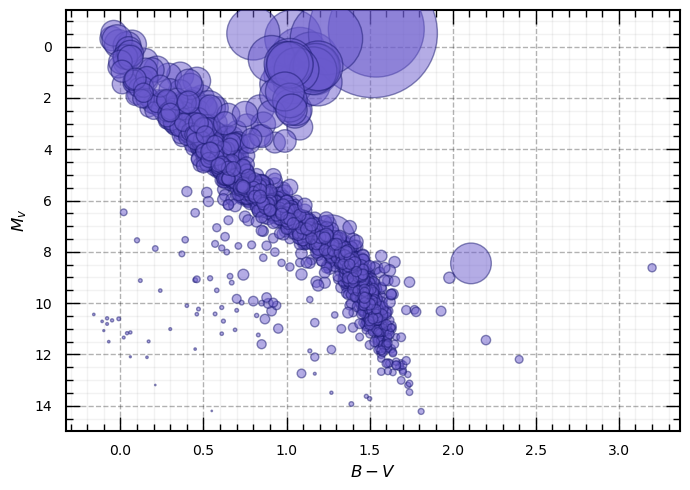

In [8]:
fig, axs = plt.subplots ( figsize = (7,5), dpi = 100 )

plt.scatter ( 'B-V', 'Mv', data = hr, color = 'slateblue', edgecolors = 'midnightblue', 
             s = hr['R*(Rsun)']*100, alpha = 0.5, zorder = 10 )
axs.invert_yaxis()

axs.set_xlabel ( r'$B-V$', size = 12 )
axs.set_ylabel ( r'$M_v$', size = 12 )

custom_axes ( axs )
    
fig.tight_layout()
plt.show()

## Visualice las temperaturas efectivas ($T_{ef}$ ), recordando la correspondencia entre la $T_{ef}$ y el color $B − V$.


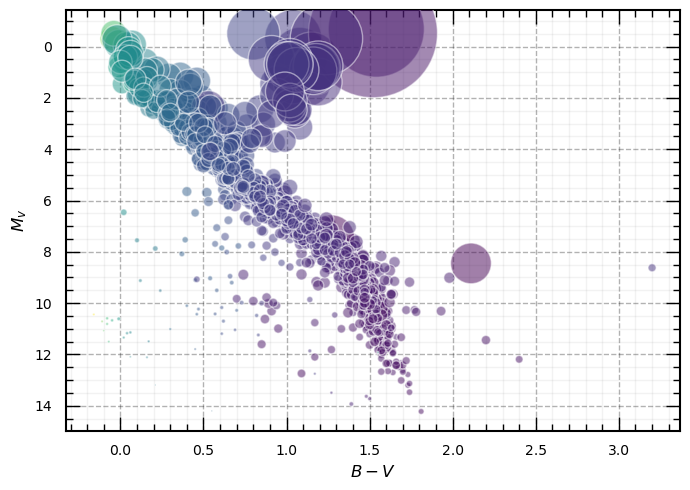

In [9]:
fig, axs = plt.subplots ( figsize = (7,5), dpi = 100 )

plt.scatter ( 'B-V', 'Mv', data = hr, c = hr['Teff'], edgecolors = 'white', 
             s = hr['R*(Rsun)']*100, alpha = 0.5, zorder = 10 )
axs.invert_yaxis()

axs.set_xlabel ( r'$B-V$', size = 12 )
axs.set_ylabel ( r'$M_v$', size = 12 )

custom_axes ( axs )
    
fig.tight_layout()
plt.show()

In [10]:
hr['Teff'].describe()

count     2333.000000
mean      4879.582940
std       1253.133893
min       2685.000000
25%       3870.000000
50%       4701.000000
75%       5664.000000
max      15675.000000
Name: Teff, dtype: float64

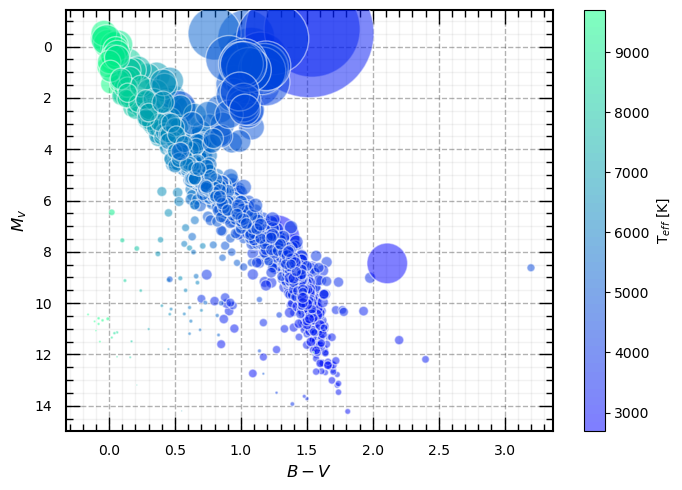

In [11]:
fig, axs = plt.subplots ( figsize = (7,5), dpi = 100 )

plt.scatter ( 'B-V', 'Mv', data = hr, c = hr['Teff'], edgecolors = 'white', 
             s = hr['R*(Rsun)']*100, alpha = 0.5, cmap = plt.cm.get_cmap('winter', 50), 
             vmin = 2700, vmax = 9700, 
             zorder = 10 )
axs.invert_yaxis()

axs.set_xlabel ( r'$B-V$', size = 12 )
axs.set_ylabel ( r'$M_v$', size = 12 )

custom_axes ( axs )
    
plt.colorbar ( label = 'T$_{eff}$ [K]' )
fig.tight_layout()
plt.show()

## Realice el diagrama HR teórico: $\log(L/L_\odot)$ vs. $\log(T_{ef})$. Superponga rectas de radio estelar constante.

In [12]:
hr['Lbol'].describe()

count    2347.000000
mean        3.138057
std        24.224077
min         0.000000
25%         0.070000
50%         0.230000
75%         0.925000
max       878.370000
Name: Lbol, dtype: float64

In [13]:
import numpy as np

hr['logteff'] = np.log10 ( hr['Teff'] )

# Calculo Mbol (es decir, log(L)), pero hago la cuenta solo si Lbol > 0
hr['Mbol'] = hr['Lbol'].map ( lambda x: np.log10 ( x ) if pd.notnull(x) else np.nan ) 

C:\Users\Usuario\AppData\Local\Temp/ipykernel_4556/3061499728.py:6: RuntimeWarning: divide by zero encountered in log10
  hr['Mbol'] = hr['Lbol'].map ( lambda x: np.log10 ( x ) if pd.notnull(x) else np.nan )


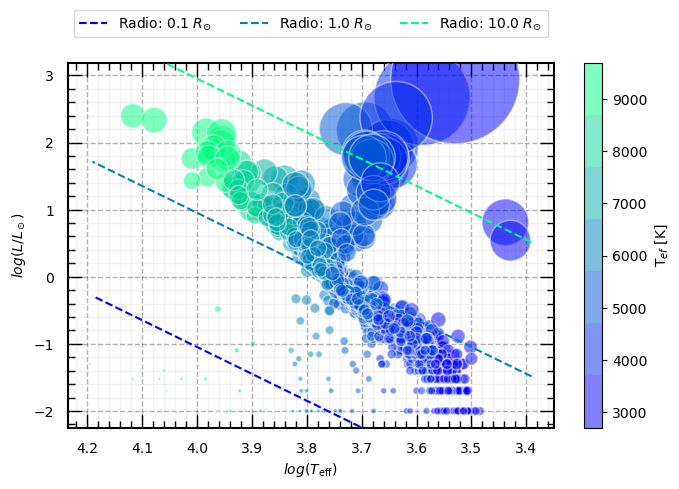

In [14]:
from matplotlib.pyplot import cm
fig, axs = plt.subplots ( figsize = (7,5), dpi = 100 )

plt.scatter ( 'logteff', 'Mbol', data = hr, c = hr['Teff'], edgecolors = 'white', 
             s = hr['R*(Rsun)']*100, alpha = 0.5, cmap = plt.cm.get_cmap('winter', 7), 
             vmin = 2700, vmax = 9700, label = None, 
             zorder = 10 )
axs.invert_xaxis()

axs.set_xlabel ( r'$log (T_\mathrm{eff}$)' )
axs.set_ylabel ( r'$log(L/L_\odot)$' )

#·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--
# Rectas de radio constante 
xi, xf = axs.get_xlim() # Pide los valores extremos en x.
yi, yf = axs.get_ylim() 

x = np.arange ( xf, xi , 0.1 )
def f(x, radio, T):
    return 4 * x + 2 * np.log10( radio ) - 4 * np.log10( T )

color=iter(cm.winter(np.linspace(0,1,3)))
for radio in [ 0.1, 1.0, 10.0 ]:
    c = next(color)
    y = f ( x, radio, 5778 ) #5778 es la temperatura solar
    axs.plot ( x , y, linestyle = "--", label = "Radio: %3.1f $R_{\odot}$" %(radio), zorder = 15, color = c )


#·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--

custom_axes ( axs )
axs.set_ylim ( yi, yf )

plt.colorbar ( label = 'T$_{ef}$ [K]' )
plt.legend ( loc = "lower center", bbox_to_anchor = (0.5, 1.05), ncol = 3 )

fig.tight_layout()
plt.show()

# Obtenga el diagrama HR espectroscópico: $\log(\mathcal{L})$ vs. $\log(T_{ef})$, y superponga rectas de gravedad superficial constantes ([Langer y Kudritzki, 2014, A\&A, 564, A52](https://ui.adsabs.harvard.edu/abs/2014A%26A...564A..52L/abstract)) utilizando:

$L = 4 \pi R^2 \sigma T^4$  
$g = \frac{GM}{R^2}$

Se puede definir el HR espectroscópico como un gráfico donde se relacionan parámetros completamente extraíbles de los espectros, i.e. $T_{ef}$ y gravedad superficial ($g$). Así, combinando las ecuaciones de $L$ y $g$, podemos definir una nueva Luminosidad ($\mathcal{L}= L/M$).


In [17]:
hr['logteff'] = np.log10( hr['Teff'] )
hr['L_sp'] = 4 * hr['logteff'] - hr['log(g)'] - 4 * np.log10(5778) + 4.0

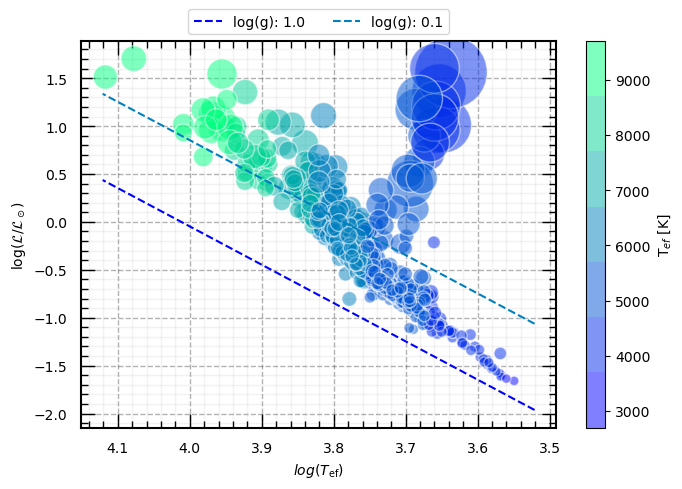

In [35]:
fig, axs = plt.subplots ( figsize = (7,5), dpi = 100 )

plt.scatter ( 'logteff', 'L_sp', data = hr, c = hr['Teff'], edgecolors = 'white', 
             s = hr['R*(Rsun)']*100, alpha = 0.5, cmap = plt.cm.get_cmap('winter', 7), 
             vmin = 2700, vmax = 9700, label = None, 
             zorder = 10 )
axs.invert_xaxis()

#·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--
# Rectas de gravedad constante
xi, xf = axs.get_xlim() # Pide los valores extremos en x.
yi, yf = axs.get_ylim() 

x = np.arange ( xf, xi , 0.1 )
def h(x,g,T):
    return 4 * x - g - 4 * np.log10(T)        #https://www.aanda.org/articles/aa/pdf/2014/04/aa23374-14.pdf

color=iter(cm.winter(np.linspace(0,1,3)))
for g in [1, 0.1]:
    c = next(color)
    y = h (x, g, 5778)
    axs.plot (x, y, linestyle = '--', label = 'log(g): %1.1f'%g, color = c, zorder = 15)
#·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--

axs.set_xlabel ( r'$log (T_\mathrm{ef}$)' )
axs.set_ylabel ( r'$\log(\mathcal{L}/\mathcal{L}_\odot)$' )
plt.legend ( loc = "lower center", bbox_to_anchor = (0.5, 1.0), ncol = 3 )

custom_axes ( axs )

plt.colorbar ( label = 'T$_{ef}$ [K]' )
fig.tight_layout()
plt.show()

# Por último, realice un diagrama $\log(g)$ vs. $\log(T_{ef})$.

In [43]:
hr['[Fe/H]-VF05'].describe()

count    420.000000
mean      -0.045619
std        0.258605
min       -1.480000
25%       -0.180000
50%        0.000000
75%        0.120000
max        0.460000
Name: [Fe/H]-VF05, dtype: float64

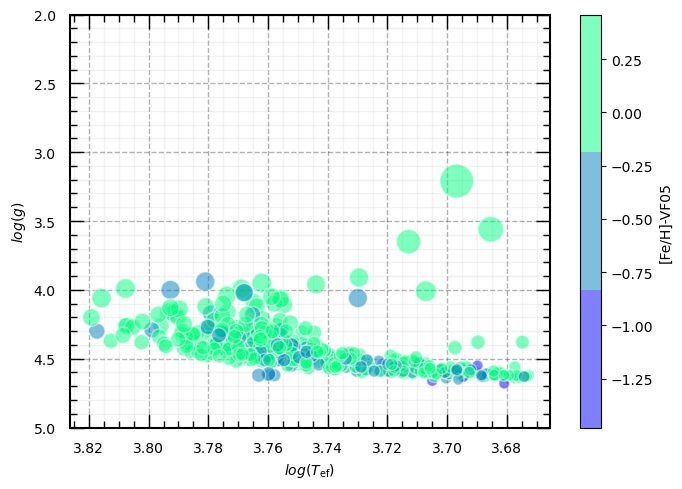

In [75]:
fig, axs = plt.subplots ( figsize = (7,5), dpi = 100 )

plt.scatter ( 'logteff', 'log(g)', data = hr, c = hr['[Fe/H]-VF05'], edgecolors = 'white', 
             s = hr['R*(Rsun)']*100, alpha = 0.5, cmap = plt.cm.get_cmap('winter', 3), 
             vmin = -1.48, vmax = 0.46, label = None, 
             zorder = 10 )
axs.invert_xaxis()
axs.invert_yaxis()

axs.set_xlabel ( r'$log (T_\mathrm{ef}$)' )
axs.set_ylabel ( r'$log(g)$' )

custom_axes ( axs )

axs.set_ylim (5,2)
plt.colorbar ( label = '[Fe/H]-VF05' )
fig.tight_layout()
plt.show()

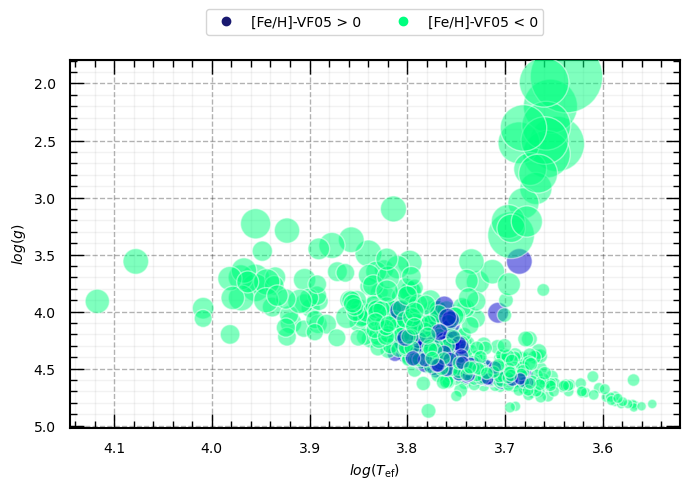

In [39]:
import matplotlib.patches as mpatches

fig, axs = plt.subplots ( figsize = (7,5), dpi = 100 )

plt.scatter ( 'logteff', 'log(g)', data = hr, c = np.where( hr['[Fe/H]-VF05'] > 0, 'mediumblue', 'springgreen' ), 
             edgecolors = 'white', s = hr['R*(Rsun)']*100, alpha = 0.5, label = None, zorder = 10)

axs.invert_xaxis()
axs.invert_yaxis()

axs.set_xlabel ( r'$log (T_\mathrm{ef}$)' )
axs.set_ylabel ( r'$log(g)$' )

custom_axes ( axs )

colors = [ 'midnightblue', 'springgreen' ]
texts = [ '[Fe/H]-VF05 > 0', '[Fe/H]-VF05 < 0' ]
patches = [ plt.plot([],[], marker = "o", ls = "", color = colors[i], 
                     label = "{:s}".format(texts[i]) )[0]  for i in range(len(texts)) ]
plt.legend( handles = patches, bbox_to_anchor = (0.5, 1.05),  loc='lower center', ncol = 2 )

fig.tight_layout()
plt.show()